In [ ]:
import shutil

shutil.make_archive("my_results", "zip", "/kaggle/working/food101_split")

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/food41")

print("Path to dataset files:", path)

In [ ]:
import os

new_folder_name = "Scratch_models"
# Define the full path
path = os.path.join("/kaggle/working/", new_folder_name) 

# Create the directory
os.makedirs(path, exist_ok=True)

print(f"Directory '{path}' created.")


In [1]:
import torch
from pathlib import Path
import os
image_path = Path("/kaggle/input/datasets/kmader/food41/images")
image_path

img_path_list = list(image_path.glob("*/*jpg"))
len(img_path_list)


101000

donuts


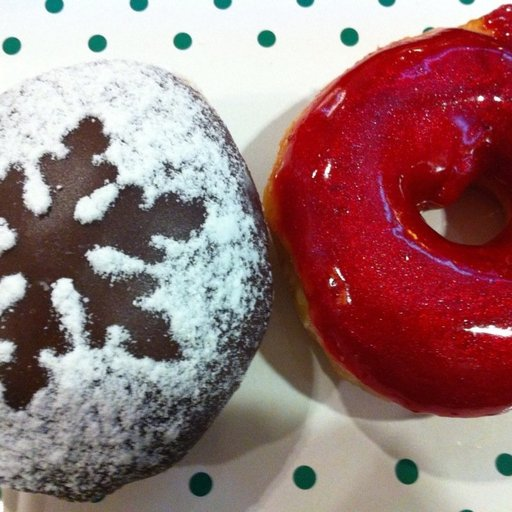

In [2]:
import random
from PIL import Image
img = random.choice(img_path_list)
img_class = img.parent.stem
print(img_class)
img = Image.open(img)
img

In [4]:
# import os
# import shutil
# import random
# from tqdm import tqdm

# src_dir = image_path
# base_dir = "/kaggle/working/food101_split"

# train_dir = os.path.join(base_dir, "train")
# val_dir = os.path.join(base_dir, "val")

# split_ratio = 0.8
# random.seed(42)

# classes = [c for c in os.listdir(src_dir) if os.path.isdir(os.path.join(src_dir, c))]

# for class_name in tqdm(classes):
#     class_path = os.path.join(src_dir, class_name)
#     images = os.listdir(class_path)
#     random.shuffle(images)

#     split_index = int(len(images) * split_ratio)
#     train_imgs = images[:split_index]
#     val_imgs = images[split_index:]

#     os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
#     os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

#     for img in train_imgs:
#         shutil.copy2(os.path.join(class_path, img),
#                      os.path.join(train_dir, class_name, img))

#     for img in val_imgs:
#         shutil.copy2(os.path.join(class_path, img),
#                      os.path.join(val_dir, class_name, img))

# print("✅ DONE — 101 classes split correctly.")


In [5]:
import torch
from pathlib import Path
import os
image_path = Path("/kaggle/working/food101_split")
image_path

img_path_list = list(image_path.glob("*/*"))
len(img_path_list)


202

In [6]:
train_dir = image_path/"train"
test_dir = image_path/"val"

train_dir,test_dir

(PosixPath('/kaggle/working/food101_split/train'),
 PosixPath('/kaggle/working/food101_split/val'))

Class: carrot_cake


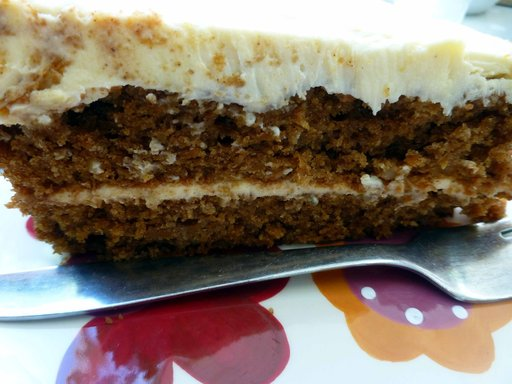

In [7]:
import random
from pathlib import Path
import os
from PIL import Image


train_img_list= list(train_dir.glob("*/*jpg"))
train_rand_img = random.choice(train_img_list)
print(f"Class: {train_rand_img.parent.stem}")
img = Image.open(train_rand_img)
img


In [8]:
# transform
from torchvision.transforms import v2
train_transform = v2.Compose([
    v2.Resize((288, 288)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    v2.RandomCrop(260),
    v2.TrivialAugmentWide(),
    v2.ToTensor(), # 2. Turn image values to between 0 & 1
    v2.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225])
])

test_transform = v2.Compose([
    v2.Resize(size=(288,288)),
    v2.RandomCrop(260),
    v2.ToTensor(),
    v2.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225])
])

train_transform,test_transform

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


(Compose(
       Resize(size=[288, 288], interpolation=InterpolationMode.BILINEAR, antialias=True)
       RandomCrop(size=(260, 260), pad_if_needed=False, fill=0, padding_mode=constant)
       TrivialAugmentWide(interpolation=InterpolationMode.NEAREST, num_magnitude_bins=31)
       ToTensor()
       Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
 ),
 Compose(
       Resize(size=[288, 288], interpolation=InterpolationMode.BILINEAR, antialias=True)
       RandomCrop(size=(260, 260), pad_if_needed=False, fill=0, padding_mode=constant)
       ToTensor()
       Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
 ))

In [10]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [11]:
# Get the transforms used to create our pretrained weights
import torchvision

weights = torchvision.models.EfficientNet_B4_Weights.DEFAULT
model = torchvision.models.efficientnet_b4(weights = weights).to(device)


In [12]:
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[380]
    resize_size=[384]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [13]:
# preparing dataset
from torchvision import datasets

train_dataset = datasets.ImageFolder(root=train_dir,
                                     transform=auto_transforms
                                     )

test_dataset = datasets.ImageFolder(root=test_dir,
                                     transform=auto_transforms
                                     )

len(train_dataset), len(test_dataset)

train_dataset,test_dataset

(Dataset ImageFolder
     Number of datapoints: 80800
     Root location: /kaggle/working/food101_split/train
     StandardTransform
 Transform: ImageClassification(
                crop_size=[380]
                resize_size=[384]
                mean=[0.485, 0.456, 0.406]
                std=[0.229, 0.224, 0.225]
                interpolation=InterpolationMode.BICUBIC
            ),
 Dataset ImageFolder
     Number of datapoints: 20200
     Root location: /kaggle/working/food101_split/val
     StandardTransform
 Transform: ImageClassification(
                crop_size=[380]
                resize_size=[384]
                mean=[0.485, 0.456, 0.406]
                std=[0.229, 0.224, 0.225]
                interpolation=InterpolationMode.BICUBIC
            ))

In [14]:
classes = train_dataset.classes
print(classes)
class_idx = train_dataset.class_to_idx
print(class_idx)

['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheese_plate', 'cheesecake', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice', 'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'huevos_rancheros', 'hummus', 'ice_cream', 'lasagna', 'lobster_bisque', 'lobster_roll_sandwich', 'macaroni_and_cheese', 'macarons', 'miso_sou

In [15]:
#preparing dataloader
from torch.utils.data import DataLoader
import os

BATCH_SIZE = 16
NUM_WORKERS = os.cpu_count()

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size = BATCH_SIZE,
                              num_workers= NUM_WORKERS,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_dataset,
                              batch_size = BATCH_SIZE,
                              num_workers= NUM_WORKERS,
                              shuffle=False)

NUM_WORKERS
len(train_dataloader)

5050

## Sttting up weights/pre-trainrd models

In [16]:
# Install torchinfo if it's not available, import it if it is
try:
    import torchinfo
except:
    !pip install torchinfo
    import torchinfo

from torchinfo import summary
# do a test pass through of an example input size

In [17]:

summary(model=model,
        input_size=(1, 3, 380, 380), # make sure this is "input_size", not "input_shape"
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 380, 380]     [1, 1000]            --                   True
├─Sequential (features)                                      [1, 3, 380, 380]     [1, 1792, 12, 12]    --                   True
│    └─Conv2dNormActivation (0)                              [1, 3, 380, 380]     [1, 48, 190, 190]    --                   True
│    │    └─Conv2d (0)                                       [1, 3, 380, 380]     [1, 48, 190, 190]    1,296                True
│    │    └─BatchNorm2d (1)                                  [1, 48, 190, 190]    [1, 48, 190, 190]    96                   True
│    │    └─SiLU (2)                                         [1, 48, 190, 190]    [1, 48, 190, 190]    --                   --
│    └─Sequential (1)                                        [1, 48, 190, 190]    [1, 24, 190,

### Freezing the base model and changing the output layer to suit our needs

In [18]:
for param in model.features.parameters():
    param.requires_grad = False

In [30]:
for param in model.features[-1].parameters():
    param.requires_grad = True

In [31]:

summary(model=model,
        input_size=(1, 3, 380, 380), # make sure this is "input_size", not "input_shape"
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 380, 380]     [1, 101]             --                   Partial
├─Sequential (features)                                      [1, 3, 380, 380]     [1, 1792, 12, 12]    --                   Partial
│    └─Conv2dNormActivation (0)                              [1, 3, 380, 380]     [1, 48, 190, 190]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 380, 380]     [1, 48, 190, 190]    (1,296)              False
│    │    └─BatchNorm2d (1)                                  [1, 48, 190, 190]    [1, 48, 190, 190]    (96)                 False
│    │    └─SiLU (2)                                         [1, 48, 190, 190]    [1, 48, 190, 190]    --                   --
│    └─Sequential (1)                                        [1, 48, 190, 190]    [1,

In [20]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

output_shape = len(classes)

model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2,inplace=True),
    torch.nn.Linear(in_features=1792,
                    out_features=output_shape,
                    bias = True).to(device)
)

##Train model

In [22]:
from torch.nn import CrossEntropyLoss
loss = CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(),
                             lr = 0.001 )

In [23]:
# accuracy function
def accuracy_fn(y_preds,true_preds):
  correct_count = torch.eq(y_preds,true_preds).sum().item()
  acc = (correct_count/len(true_preds))*100
  return acc



In [32]:
def train_fn(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)
        if (batch + 1) % 156 == 0:
            images_seen = (batch + 1) * X.size(0)
            print(f"Epoch progress: {batch+1}/{len(dataloader)} batches | "
                  f"Images seen: {images_seen} | "
                  f"Loss: {train_loss/(batch+1):.5f} | "
                  f"Acc: {train_acc/(batch+1):.4f}")
            

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [33]:
def test_fn(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
            if (batch + 1) % 156 == 0:
                print(f"After {(batch+1)* X.size(0)} images → "
                      f"Loss: {test_loss/(batch+1):.5f}, "
                      f"Acc: {test_acc/(batch+1):.4f}")

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [34]:
from tqdm.auto import tqdm
from torch import nn

# 1. Take in various parameters required for training and test steps
def run(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 3):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_fn(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss,
                                          optimizer=optimizer
                                          )
        test_loss, test_acc = test_fn(model=model,
            dataloader=test_dataloader,
            loss_fn=loss)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )
        
        torch.save(model.state_dict(),
               f"/kaggle/working/Scratch_models/scratch_model_epoch_{epoch+200}.pth")

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [ ]:
import torch
torch.cuda.empty_cache()
print(torch.cuda.memory_summary())

In [ ]:
!nvidia-smi

In [35]:

from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = run(model=model,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss,
                        epochs=12)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/12 [00:00<?, ?it/s]

Epoch progress: 156/5050 batches | Images seen: 2496 | Loss: 1.62340 | Acc: 0.5946
Epoch progress: 312/5050 batches | Images seen: 4992 | Loss: 1.59069 | Acc: 0.5974
Epoch progress: 468/5050 batches | Images seen: 7488 | Loss: 1.55084 | Acc: 0.6042
Epoch progress: 624/5050 batches | Images seen: 9984 | Loss: 1.55092 | Acc: 0.6053
Epoch progress: 780/5050 batches | Images seen: 12480 | Loss: 1.54983 | Acc: 0.6048
Epoch progress: 936/5050 batches | Images seen: 14976 | Loss: 1.53809 | Acc: 0.6058
Epoch progress: 1092/5050 batches | Images seen: 17472 | Loss: 1.53424 | Acc: 0.6069
Epoch progress: 1248/5050 batches | Images seen: 19968 | Loss: 1.52736 | Acc: 0.6077
Epoch progress: 1404/5050 batches | Images seen: 22464 | Loss: 1.51720 | Acc: 0.6115
Epoch progress: 1560/5050 batches | Images seen: 24960 | Loss: 1.50741 | Acc: 0.6138
Epoch progress: 1716/5050 batches | Images seen: 27456 | Loss: 1.50495 | Acc: 0.6145
Epoch progress: 1872/5050 batches | Images seen: 29952 | Loss: 1.50349 | Ac

In [36]:
from typing import Dict, List
import matplotlib.pyplot as plt

def plot_loss_curves(results: Dict[str, List[float]]):

    loss = results['train_loss']
    test_loss = results['test_loss']

    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    epochs = range(len(loss))

    plt.figure(figsize=(15,7))

    # Loss plot
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, marker='o', label='train_loss')
    plt.plot(epochs, test_loss, marker='o', label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylim(min(loss+test_loss)-0.02, max(loss+test_loss)+0.02)  # zoom y-axis
    plt.grid(True)
    plt.legend()

    # Accuracy plot
    plt.subplot(1,2,2)
    plt.plot(epochs, accuracy, marker='o', label='train_accuracy')
    plt.plot(epochs, test_accuracy, marker='o', label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylim(min(accuracy+test_accuracy)-0.005, max(accuracy+test_accuracy)+0.005)  # zoom y-axis
    plt.grid(True)
    plt.legend()

    plt.tight_layout()

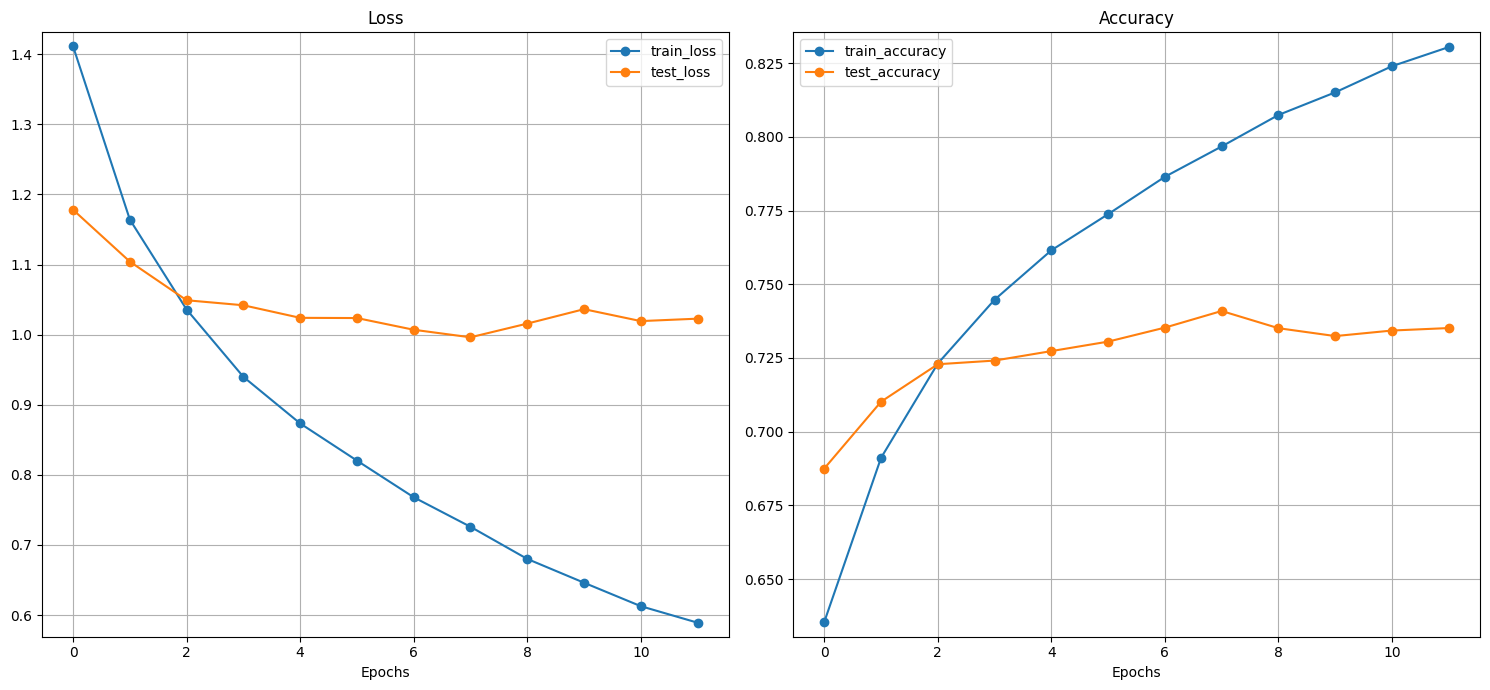

In [37]:
plot_loss_curves(model_0_results)